IMPORTING LIBRARIES

In [22]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

USING PANDAS TO READ THE DATASET , AND SPLITTING DEPENDENT AND INDEPEDENT COLUMNS.

In [23]:
df = pd.read_csv('../data/used_car_price_dataset_extended.csv')
X = df.drop("price_usd", axis=1)
y = df["price_usd"]

OTHER INFORMATION

In [24]:
df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


In [25]:
df["price_usd"].describe()

count    10000.000000
mean      7179.754532
std       2795.270940
min       1000.000000
25%       5176.547500
50%       6961.260000
75%       8993.732500
max      17647.630000
Name: price_usd, dtype: float64

Deleting None/Nan Values , delete 2000 rows , so instead we can fill that with a word Unknown , Because , it is a categorical value.

In [26]:
df["service_history"] = df["service_history"].fillna("Unknown")

SPLITTING CATEGORICAL AND NUMERICAL COLUMNS

In [27]:
numerical_cols = [
    "make_year",
    "mileage_kmpl",
    "engine_cc",
    "owner_count",
    "accidents_reported"
]

In [28]:
categorical_cols = [
    "fuel_type",
    "brand",
    "transmission",
    "color",
    "service_history",
    "insurance_valid"
]

Splitting Values into Train and Test Set.

In [29]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ENCODING AND SCALING

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ct = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)
x_train = ct.fit_transform(x_train)
x_test = ct.transform(x_test)

In [31]:
print(x_train.shape)
print(x_test.shape)

(8000, 31)
(2000, 31)


LINEAR REGRESSION MODEL

In [32]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

RANDOM FOREST

In [33]:

# from sklearn.ensemble import RandomForestRegressor


# regressor = RandomForestRegressor(n_estimators=100, random_state=42)
# regressor.fit(x_train, y_train)

# y_pred_random_forest = regressor.predict(x_test)

POLYNOMIAL REGRESSION

In [34]:
# from sklearn.preprocessing import PolynomialFeatures

# poly = PolynomialFeatures(
#     degree=2,
#     include_bias=False
# )

# x_train_poly = poly.fit_transform(x_train)
# x_test_poly = poly.transform(x_test)
# model_poly = LinearRegression()
# model_poly.fit(x_train_poly, y_train)
# y_pred_poly = model_poly.predict(x_test_poly)

SVR

In [35]:
# from sklearn.svm import SVR

# svr_model = SVR()

# svr_model.fit(x_train, y_train)

# y_pred_svr = svr_model.predict(x_test)


DECISION TREE

In [36]:
# from sklearn.tree import DecisionTreeRegressor

# dt_model = DecisionTreeRegressor(random_state=42)

# dt_model.fit(x_train, y_train)

# y_pred_dt = dt_model.predict(x_test)


R-SQUARE TEST RESULTS

In [37]:
from sklearn.metrics import r2_score

print("R^2 Score:", r2_score(y_test, y_pred))

# print("R^2 Score Random Forest:", r2_score(y_test, y_pred_random_forest))
# print("R^2 Score Decision Tree:", r2_score(y_test, y_pred_dt))
# print("R^2 Score SVR:", r2_score(y_test, y_pred_svr))
# print("R^2 Score Polynomial Regression:", r2_score(y_test, y_pred_poly))

# R^2 Score: 0.876549441054344
# R^2 Score Random Forest: 0.8519951364244247
# R^2 Score Decision Tree: 0.704202472801454
# R^2 Score SVR: 0.11642292367806106
# R^2 Score Polynomial Regression: 0.8704608345069703

R^2 Score: 0.876549441054344


TESTING (MANUAL)

In [38]:
sample_data = pd.DataFrame({
    "make_year": [2025],
    "mileage_kmpl": [58.5],
    "engine_cc": [2500],
    "fuel_type": ["Diesel"],
    "owner_count": [0],
    "brand": ["BMW"],
    "transmission": ["Automatic"],
    "color": ["White"],
    "service_history": ["Full"],
    "accidents_reported": [0],
    "insurance_valid": ["Yes"]
})

In [39]:
sample_processed = ct.transform(sample_data)

In [40]:
# predicted_price_random_forest = regressor.predict(sample_processed)
predicted_price_linear = model.predict(sample_processed)
# print("Predicted Price (Random Forest):", predicted_price_random_forest[0])
print("Predicted Price (Linear Regression):", predicted_price_linear[0])

# Predicted Price (Random Forest): 7559.497000000004
# Predicted Price (Linear Regression): 8381.892634971848

Predicted Price (Linear Regression): 15989.003233312482


SAVE MODEL 

In [41]:
import joblib

joblib.dump(model,
            "../model/vehicle_price_model.pkl")

joblib.dump(ct,
            "../model/vehicle_preprocessor.pkl")

['../model/vehicle_preprocessor.pkl']

PLOTTING - VISUALIZATION

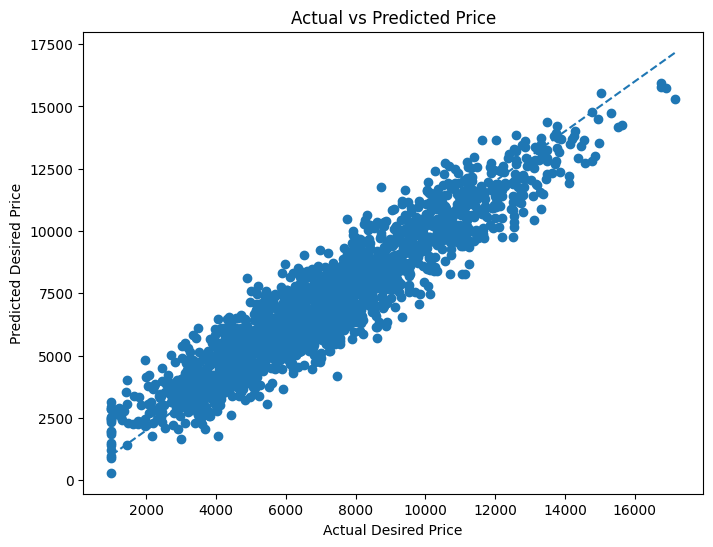

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Desired Price")
plt.ylabel("Predicted Desired Price")

plt.title("Actual vs Predicted Price")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()